# Decision Tree Evaluation on `dataset_stratified.csv`

This notebook evaluates a **Decision Tree classifier** on the stratified 20,000-row Covertype sample. The experiment is designed to satisfy the required analysis items:

- regularized/pruned Decision Trees using **`max_depth`** and **`min_samples_leaf`**;
- meaningful model-complexity sweep across several tree depths;
- learning curves using at least four training sizes;
- runtime table with fit and predict wall-clock times;
- multiclass evaluation using accuracy, macro-F1, balanced accuracy, confusion matrix, and per-class precision/recall/F1.

### Modeling choice

I use `criterion="gini"` because it is the standard scikit-learn default for CART-style Decision Trees, is computationally efficient, and is fully acceptable for this assignment. The main regularization is `max_depth`, supported by `min_samples_leaf=5` to avoid leaves formed from extremely small sample counts. This is appropriate for Covertype because the dataset is multiclass, imbalanced, and likely contains nonlinear interactions between terrain/elevation variables and binary wilderness/soil indicators.

> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "03_decision_tree"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()

# Basic data checks
TARGET_COL = "Cover_Type" if "Cover_Type" in df.columns else df.columns[-1]

missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())

summary = pd.DataFrame({
    "item": ["rows", "columns", "features", "target", "missing_values", "duplicate_rows"],
    "value": [df.shape[0], df.shape[1], df.shape[1] - 1, TARGET_COL, missing_total, duplicate_total],
})
summary

Loaded: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
Shape: 20,000 rows x 55 columns


,item,value
0,rows,20000
1,columns,55
2,features,54
3,target,Cover_Type
4,missing_values,0
5,duplicate_rows,0


## 2. Train, validation, and final test protocol

The sampled/stratified dataset is used for model development:
- 80% training set for fitting during hyperparameter/model-complexity selection;
- 20% validation set for selecting the operating point.

The untouched remainder dataset is loaded separately and used only once for final test evaluation after model selection is complete.

In [3]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 80% training, 20% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "rows": [len(X_train), len(X_valid)],
    "percent_of_total": [len(X_train) / len(X), len(X_valid) / len(X)],
})

split_summary["percent_of_total"] = (100 * split_summary["percent_of_total"]).round(1)
split_summary

,split,rows,percent_of_total
0,train,16000,80.0
1,validation,4000,20.0


In [4]:
# Load untouched remainder dataset for final testing
# This is the holdout set excluded from the sampled/stratified dataset.
if not DATASET_REMAINDER_PATH.exists():
    raise FileNotFoundError(
        f"Could not find final test dataset: {DATASET_REMAINDER_PATH}\n"
        "Run notebooks/01_eda_dataset_original.ipynb first to generate "
        "data/processed/dataset_stratified.csv and data/processed/dataset_remainder.csv."
    )

test_df = pd.read_csv(DATASET_REMAINDER_PATH)

if TARGET_COL not in test_df.columns:
    raise ValueError(
        f"Expected target column '{TARGET_COL}' in test dataset, "
        f"but found columns: {test_df.columns.tolist()}"
    )

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

# Defensive check: model-development and final-test features must match exactly.
if list(X_test.columns) != list(X.columns):
    raise ValueError(
        "Train/test feature columns do not match.\n"
        f"Training columns: {list(X.columns)}\n"
        f"Test columns: {list(X_test.columns)}"
    )

split_summary_final = pd.DataFrame({
    "split": ["train", "validation", "untouched_final_test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "source": [
        "dataset_stratified.csv",
        "dataset_stratified.csv",
        "dataset_remainder.csv",
    ],
})

split_summary_final

,split,rows,source
0,train,16000,dataset_stratified.csv
1,validation,4000,dataset_stratified.csv
2,untouched_final_test,561012,dataset_remainder.csv


# 3. Metrics

Accuracy summarizes overall correctness, but can overstate performance when large classes dominate. Therefore, I am using 3 additional metrics:

**Accuracy** overall fraction of correct predictions
**Macro-F1** unweighter average of per-class F1 scores; every cover type counts equally, making it crucial for minority classes.
**Balanced Accuracy** average recall across classes; useful to check if class frequencies differ substantially.

In this case **validtion macro-F1** is main focus. Since macro-F1 would penalize models that perform well only on most represented classes. If muptiple depths are practically tied, I would choose the shalower tree to reduce variance and keep the final it regularized

In [5]:
def evaluate_predictions(y_true, y_pred):
    """Return the required scalar classification metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def timed_fit_predict(model, X_fit, y_fit, X_eval):
    """Fit a model and time both fitting and prediction."""
    start = time.perf_counter()
    model.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(X_eval)
    predict_seconds = time.perf_counter() - start
    return pred, fit_seconds, predict_seconds

# 4. Model-completxity curve: tree deplth sweep
`max_deplth` is a direct and interpretable regularization control for Decition Trees because:
very shallow trees should underfit
very deep trees may overfit
intermeidate depth may provide the best validation macro-F1

The sweep covers a broad range: 2, 4, 6, 8, 10, 14, 18, 22, None. This is intentionally wider than tiny adjacent values so the curve can reveal underfitting, overfitting, or saturation.

I keep min_samples_leaf=5 fixed to reduce unstable leaves produced by very small sample groups, which matters for the minority Covertype classes.

In [6]:
DEPTH_VALUES = [2, 4, 6, 8, 10, 14, 18, 22]
MIN_SAMPLES_LEAF = 5
CRITERION = "gini"
mc_rows = []
models_by_depth = {}

for depth in DEPTH_VALUES:
    model = DecisionTreeClassifier(
        criterion=CRITERION,
        max_depth=depth,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
    )

    # Time fit and validation prediction
    valid_pred, fit_s, valid_pred_s = timed_fit_predict(model, X_train, y_train, X_valid)
    train_pred_start = time.perf_counter()
    train_pred = model.predict(X_train)
    train_pred_s = time.perf_counter() - train_pred_start

    train_metrics = evaluate_predictions(y_train, train_pred)
    valid_metrics = evaluate_predictions(y_valid, valid_pred)

    row = {
        "max_depth": "None" if depth is None else depth,
        "actual_depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
        "min_samples_leaf": MIN_SAMPLES_LEAF,
        "criterion": CRITERION,
        "fit_seconds": fit_s,
        "train_predict_seconds": train_pred_s,
        "valid_predict_seconds": valid_pred_s,
    }
    for k, v in train_metrics.items():
        row[f"train_{k}"] = v
    for k, v in valid_metrics.items():
        row[f"valid_{k}"] = v

    mc_rows.append(row)
    models_by_depth[depth] = model

mc_results = pd.DataFrame(mc_rows)
mc_results.to_csv(RESULTS_MODEL_COMPARISON_DIR / "01_dt_model_complexity_results.csv", index=False)
mc_results.sort_values(["valid_macro_f1", "valid_balanced_accuracy"], ascending=False)

,max_depth,actual_depth,n_leaves,min_samples_leaf,criterion,fit_seconds,train_predict_seconds,valid_predict_seconds,train_accuracy,train_macro_f1,train_balanced_accuracy,valid_accuracy,valid_macro_f1,valid_balanced_accuracy
7,22,22,1333,5,gini,0.163215,0.005004,0.002282,0.893750,0.816819,0.789520,0.76450,0.651615,0.632086
6,18,18,1121,5,gini,0.154777,0.004860,0.002303,0.878125,0.802633,0.771100,0.76975,0.646638,0.624520
5,14,14,797,5,gini,0.141271,0.004691,0.002251,0.843250,0.768735,0.734412,0.76200,0.639611,0.614037
4,10,10,398,5,gini,0.111567,0.004252,0.002097,0.804312,0.702449,0.660910,0.75575,0.593614,0.572969
3,8,8,185,5,gini,0.092370,0.004048,0.002016,0.769500,0.620248,0.574692,0.73550,0.530285,0.503335
2,6,6,61,5,gini,0.071449,0.003878,0.002025,0.732938,0.527684,0.489551,0.72200,0.465965,0.448805
1,4,4,16,5,gini,0.050207,0.003850,0.001995,0.697187,0.458967,0.450024,0.69350,0.410294,0.410143
0,2,2,4,5,gini,0.029027,0.003696,0.002026,0.676625,0.292576,0.309690,0.67525,0.293463,0.314514


In [7]:
# after selecting operating point by validation macro-F1, with a small tie tolerance ->
# multiple depth are withing 0.002 macro-F1 of the best validation results.
selection_table = mc_results.copy()
selection_table["depth_for_sort"] = selection_table["max_depth"].replace("None", 10_000).astype(int)

TIE_TOLERANCE = 0.002
best_valid_macro_f1 = selection_table["valid_macro_f1"].max()
candidates = selection_table[
    selection_table["valid_macro_f1"] >= best_valid_macro_f1 - TIE_TOLERANCE
    ].copy()

best_row = candidates.sort_values(
    ["depth_for_sort", "valid_macro_f1", "valid_balanced_accuracy"],
    ascending=[True, False, False],
).iloc[0]

best_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])

print("Selected Parameters:")
print(f"  criterion         = {CRITERION}")
print(f"  max_depth         = {best_depth}")
print(f"  min_samples_leaf  = {MIN_SAMPLES_LEAF}")
print(f"  selection rule    = simplest depth within {TIE_TOLERANCE:.3f} validation macro-F1 of the best observed value")
print(f"  best observed validation macro-F1 = {best_valid_macro_f1:.4f}")
print(f"  selected validation macro-F1 = {best_row['valid_macro_f1']:.4f}")
print(f"  selected validation balanced accuracy = {best_row['valid_balanced_accuracy']:.4f}")
print(f"  selected validation accuracy = {best_row['valid_accuracy']:.4f}")

Selected Parameters:
  criterion         = gini
  max_depth         = 22
  min_samples_leaf  = 5
  selection rule    = simplest depth within 0.002 validation macro-F1 of the best observed value
  best observed validation macro-F1 = 0.6516
  selected validation macro-F1 = 0.6516
  selected validation balanced accuracy = 0.6321
  selected validation accuracy = 0.7645


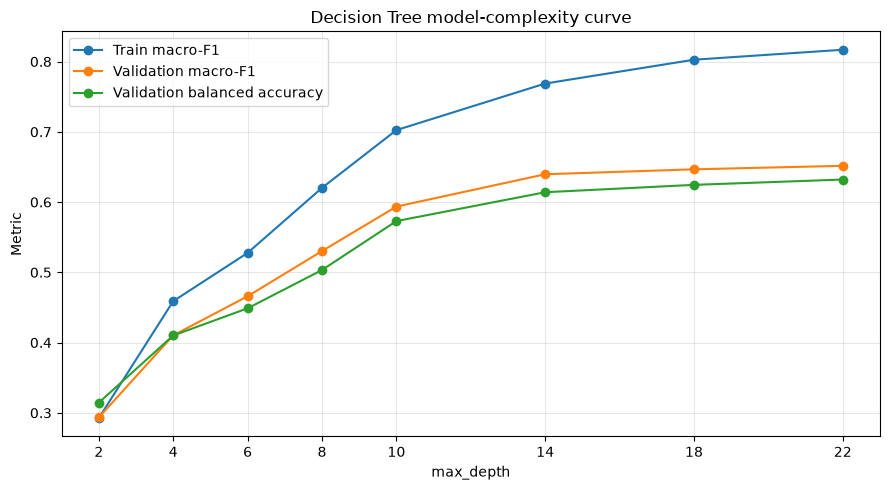

In [8]:
# plotting model-complexity figure validation vs max-depht
plot_df = mc_results.copy()
plot_df["max_depth_plot"] = plot_df["max_depth"].replace("None", max([d for d in DEPTH_VALUES if d is not None]) + 4).astype(int)
plot_df["max_depth_label"] = plot_df["max_depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(plot_df["max_depth_plot"], plot_df["train_macro_f1"], marker="o", label="Train macro-F1")
plt.plot(plot_df["max_depth_plot"], plot_df["valid_macro_f1"], marker="o", label="Validation macro-F1")
plt.plot(plot_df["max_depth_plot"], plot_df["valid_balanced_accuracy"], marker="o", label="Validation balanced accuracy")
plt.xticks(plot_df["max_depth_plot"], plot_df["max_depth_label"])
plt.xlabel("max_depth")
plt.ylabel("Metric")
plt.title("Decision Tree model-complexity curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "01_dt_model_complexity_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Learning curves
Checking whether more data is helping model or model show bias/variance by using selected tree configuration to evaluate training and valiation metrics over five training sizes 10%, 25%, 50%, 75% and 100%. 

In [9]:
TRAIN_SIZE_FRAC = [0.10, 0.25, 0.50, 0.75, 1.00]
lc_rows = []

for frac in TRAIN_SIZE_FRAC:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train,
            y_train,
            train_size=frac,
            random_state=RANDOM_STATE,
            stratify=y_train,
        )
    else:
        X_sub, y_sub = X_train, y_train

    model = DecisionTreeClassifier(
        criterion=CRITERION,
        max_depth=best_depth,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
    )

    valid_pred, fit_s, valid_pred_s = timed_fit_predict(model, X_sub, y_sub, X_valid)
    train_pred_start = time.perf_counter()
    train_pred = model.predict(X_sub)
    train_pred_s = time.perf_counter() - train_pred_start

    train_metrics = evaluate_predictions(y_sub, train_pred)
    valid_metrics = evaluate_predictions(y_valid, valid_pred)

    row = {
        "train_fractions": frac,
        "train_rows": len(X_sub),
        "fit_seconds": fit_s,
        "train_predict_seconds": train_pred_s,
        "valid_predict_seconds": valid_pred_s,
    }
    for k, v in train_metrics.items():
        row[f"train_{k}"] = v
    for k, v in valid_metrics.items():
        row[f"valid_{k}"] = v

    lc_rows.append(row)

lc_results = pd.DataFrame(lc_rows)
lc_results.to_csv(RESULTS_MODEL_COMPARISON_DIR / "02_dt_learning_curve_results.csv", index=False)
lc_results

,train_fractions,train_rows,fit_seconds,train_predict_seconds,valid_predict_seconds,train_accuracy,train_macro_f1,train_balanced_accuracy,valid_accuracy,valid_macro_f1,valid_balanced_accuracy
0,0.10,1600,0.016303,0.001489,0.001992,0.867500,0.634168,0.611691,0.67950,0.451745,0.449208
1,0.25,4000,0.040253,0.001932,0.002005,0.876000,0.739665,0.701256,0.69875,0.520927,0.507569
2,0.50,8000,0.120883,0.003885,0.002851,0.881375,0.804115,0.782664,0.72175,0.561422,0.556130
3,0.75,12000,0.170131,0.005505,0.003155,0.892250,0.815311,0.798591,0.75225,0.616644,0.614158
4,1.00,16000,0.227072,0.006917,0.003197,0.893750,0.816819,0.789520,0.76450,0.651615,0.632086


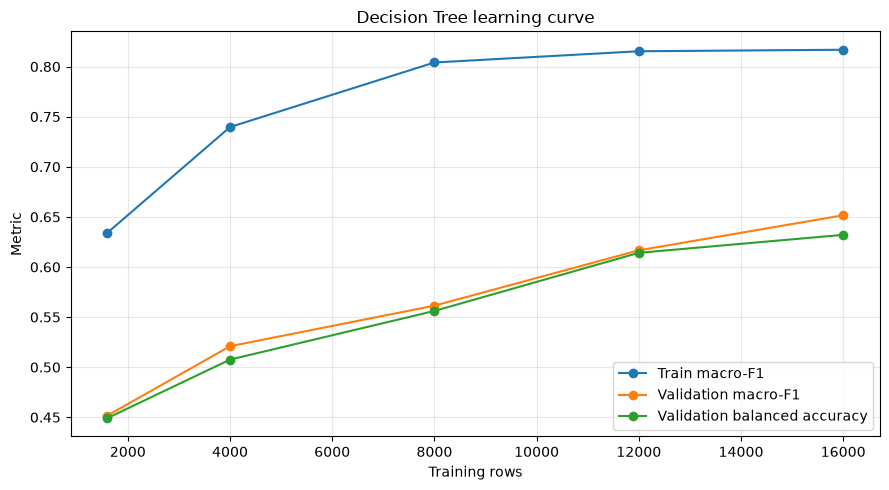

In [10]:
# plotting curve figures: training and validation macro-F1 vs training size
plt.figure(figsize=(9, 5))
plt.plot(lc_results["train_rows"], lc_results["train_macro_f1"], marker="o", label="Train macro-F1")
plt.plot(lc_results["train_rows"], lc_results["valid_macro_f1"], marker="o", label="Validation macro-F1")
plt.plot(lc_results["train_rows"], lc_results["valid_balanced_accuracy"], marker="o", label="Validation balanced accuracy")
plt.xlabel("Training rows")
plt.ylabel("Metric")
plt.title("Decision Tree learning curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "02_dt_learning_curve.png", dpi=160, bbox_inches="tight")
plt.show()

In [11]:
# Brief automatic diagnosis of the learning curve
lc_first = lc_results.iloc[0]
lc_last = lc_results.iloc[-1]
lc_prev = lc_results.iloc[-2]

final_gap = lc_last["train_macro_f1"] - lc_last["valid_macro_f1"]
recent_valid_gain = lc_last["valid_macro_f1"] - lc_prev["valid_macro_f1"]
total_valid_gain = lc_last["valid_macro_f1"] - lc_first["valid_macro_f1"]

print("Learning-curve diagnosis:")
print(f"  Total validation macro-F1 gain from smallest to full training size: {total_valid_gain:.4f}.")
print(f"  Recent validation macro-F1 gain from 75% to 100% training data: {recent_valid_gain:.4f}.")
print(f"  Final train-validation macro-F1 gap: {final_gap:.4f}.")

if final_gap > 0.10 and recent_valid_gain > 0.005:
    print("  Diagnosis: variance remains visible and more data may help.")
elif final_gap > 0.10:
    print("  Diagnosis: variance/overfitting is visible, but the curve is starting to saturate.")
elif lc_last["valid_macro_f1"] < 0.60 and final_gap < 0.05:
    print("  Diagnosis: possible bias/underfitting; a single regularized tree may be too limited.")
else:
    print("  Diagnosis: validation performance is relatively stable; additional data may help only modestly unless model capacity changes.")

Learning-curve diagnosis:
  Total validation macro-F1 gain from smallest to full training size: 0.1999.
  Recent validation macro-F1 gain from 75% to 100% training data: 0.0350.
  Final train-validation macro-F1 gap: 0.1652.
  Diagnosis: variance remains visible and more data may help.


## 6 Final model at justified operating point.
Using hyperparameters selected by validation macro-F1 and is refit on the combined training + validation data. The untouched test set is used for final evaluation only


In [12]:
# Guard against out-of-order notebook execution.
required_test_vars = ["X_test", "y_test"]
missing_test_vars = [name for name in required_test_vars if name not in globals()]
if missing_test_vars:
    raise NameError(
        f"Missing final test variables: {missing_test_vars}. "
        "Run the final-test dataset loading cell before this cell."
    )

final_model = DecisionTreeClassifier(
    criterion=CRITERION,
    max_depth=best_depth,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
)

# Runtime for final fit and test prediction
start = time.perf_counter()
final_model.fit(X, y)
final_fit_seconds = time.perf_counter() - start

start = time.perf_counter()
y_test_pred = final_model.predict(X_test)
final_predict_seconds = time.perf_counter() - start

test_metrics = evaluate_predictions(y_test, y_test_pred)
final_metrics = pd.DataFrame([{
    "criterion": CRITERION,
    "max_depth": "None" if best_depth is None else best_depth,
    "actual_depth": final_model.get_depth(),
    "n_leaves": final_model.get_n_leaves(),
    "min_samples_leaf": MIN_SAMPLES_LEAF,
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
}])
final_metrics.to_csv(RESULTS_METRICS_DIR / "01_dt_final_test_metrics.csv", index=False)
final_metrics

,criterion,max_depth,actual_depth,n_leaves,min_samples_leaf,test_accuracy,test_macro_f1,test_balanced_accuracy
0,gini,22,22,1614,5,0.766665,0.658665,0.639017


## 7. Runtime table and hardware note
Reporting the runtime measured on the machine executing the notebook

In [13]:
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / (1024 ** 3)
    cpu_count = psutil.cpu_count(logical=True)
except Exception:
    ram_gb = np.nan
    cpu_count = os.cpu_count()

hardware_note = pd.DataFrame([{
    "python": platform.python_version(),
    "platform": platform.platform(),
    "processor": platform.processor() or "not reported",
    "logical_cpu_count": cpu_count,
    "ram_gb": round(ram_gb, 2) if not pd.isna(ram_gb) else "not reported",
}])
hardware_note.to_csv(RESULTS_RUNTIME_DIR / "02_dt_hardware_note.csv", index=False)
hardware_note

,python,platform,processor,logical_cpu_count,ram_gb
0,3.11.15,Linux-6.8.0-124-generic-x86_64-with-glibc2.39,x86_64,12,15.29


In [14]:
runtime_table = pd.DataFrame([
    {
        "stage": "model-complexity sweep",
        "models_fit": len(DEPTH_VALUES),
        "fit_seconds_total": mc_results["fit_seconds"].sum(),
        "predict_seconds_total": mc_results["valid_predict_seconds"].sum(),
        "rows_fit_per_model": len(X_train),
        "rows_pred_per_model": len(X_valid),
    },
    {
        "stage": "learning curve",
        "models_fit": len(TRAIN_SIZE_FRAC),
        "fit_seconds_total": lc_results["fit_seconds"].sum(),
        "predict_seconds_total": lc_results["valid_predict_seconds"].sum(),
        "rows_fit_per_model": "varies",
        "rows_pred_per_model": len(X_valid),
    },
    {
        "stage": "final selected model",
        "models_fit": 1,
        "fit_seconds_total": final_fit_seconds,
        "predict_seconds_total": final_predict_seconds,
        "rows_fit_per_model": len(X),
        "rows_pred_per_model": len(X_test),
    },
])

runtime_table["fit_seconds_total"] = runtime_table["fit_seconds_total"].astype(float).round(6)
runtime_table["predict_seconds_total"] = runtime_table["predict_seconds_total"].astype(float).round(6)
runtime_table.to_csv(RESULTS_RUNTIME_DIR / "03_dt_runtime_table.csv", index=False)
runtime_table

,stage,models_fit,fit_seconds_total,predict_seconds_total,rows_fit_per_model,rows_pred_per_model
0,model-complexity sweep,8,0.813883,0.016994,16000,4000
1,learning curve,5,0.574643,0.013199,varies,4000
2,final selected model,1,0.255558,0.187817,20000,561012


## 8 Multiclass evaluatoin: confusion matrix and per-class metrics
Evaluating final selected Decision Tree on the remainder helodout test set. The classification report gives precison, recall and F1 for every class

In [15]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in labels], columns=[f"pred_{c}" for c in labels])
cm_df.to_csv(RESULTS_CONFUSION_MATRICES_DIR / "04_dt_confusion_matrix.csv")
cm_df

,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7
true_1,156280,43455,49,0,426,170,4168
true_2,45504,220177,2871,7,2299,1906,785
true_3,48,3708,26407,604,191,3523,42
true_4,0,17,934,1526,0,176,0
true_5,799,4811,238,0,3213,101,4
true_6,108,2917,5059,200,41,8444,0
true_7,5200,543,0,0,0,0,14061


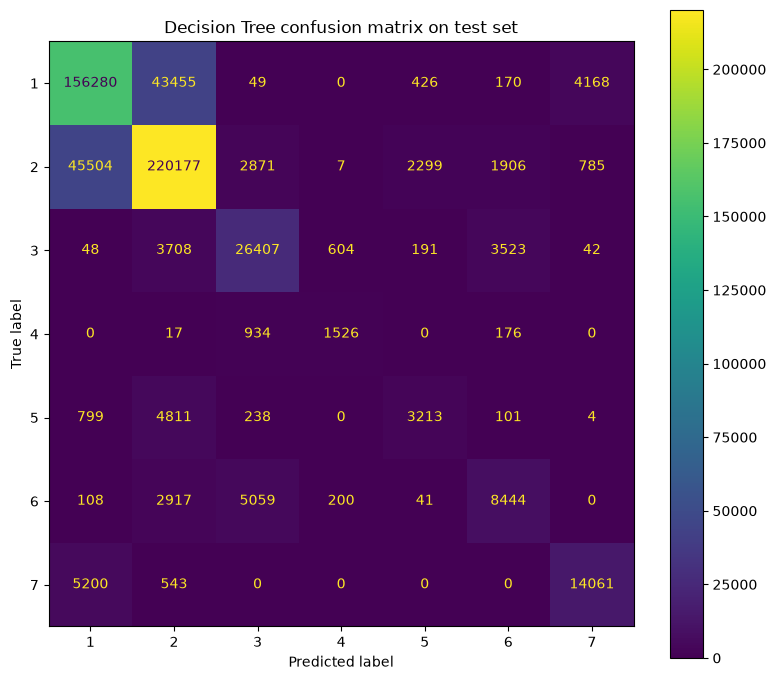

In [16]:
# plotting confusion matrix
plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", ax=plt.gca())
plt.title("Decision Tree confusion matrix on test set")
plt.tight_layout()
plt.savefig(FIG_CONFUSION_MATRICES_DIR / "03_dt_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [17]:
report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=labels,
    output_dict=True,
    zero_division=0,
)

per_class_report = (
    pd.DataFrame(report_dict)
    .T
    .loc[[str(c) for c in labels], ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
per_class_report["support"] = per_class_report["support"].astype(int)
per_class_report.to_csv(RESULTS_METRICS_DIR / "05_dt_per_class_report.csv")
per_class_report

,precision,recall,f1,support
1,0.751567,0.764026,0.757745,204548
2,0.798819,0.804891,0.801843,273549
3,0.742646,0.764910,0.753614,34523
4,0.652974,0.575198,0.611623,2653
5,0.520746,0.350535,0.419014,9166
6,0.589665,0.503548,0.543215,16769
7,0.737723,0.710008,0.723600,19804


In [18]:
# Aggregating final metrics, shown beside the per-class report.
aggregate_metrics = pd.DataFrame([{
    "accuracy": test_metrics["accuracy"],
    "macro_f1": test_metrics["macro_f1"],
    "balanced_accuracy": test_metrics["balanced_accuracy"],
}])
aggregate_metrics.to_csv(RESULTS_METRICS_DIR / "06_dt_aggregate_test_metrics.csv", index=False)
aggregate_metrics

,accuracy,macro_f1,balanced_accuracy
0,0.766665,0.658665,0.639017


In [19]:
# additional helpers for automatic minority-class
support = per_class_report["support"]
minority_threshold = support.quantile(0.35)
minority_classes = support[support <= minority_threshold].index.tolist()
worst_f1 = per_class_report.sort_values("f1").head(3)
worst_recall = per_class_report.sort_values("recall").head(3)

print("Minority-class and error-pattern aids:")
print(f"  Minority/low-support classes by this split: {', '.join(minority_classes)}")
print("\nLowest F1 classes:")
print(worst_f1[["precision", "recall", "f1", "support"]].round(3))
print("\nLowest recall classes:")
print(worst_recall[["precision", "recall", "f1", "support"]].round(3))

# Find the largest off-diagonal confusions.
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
confusions = []
for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j and cm_off[i, j] > 0:
            confusions.append((true_label, pred_label, cm_off[i, j]))
confusions = sorted(confusions, key=lambda x: x[2], reverse=True)[:8]

print("\nLargest off-diagonal confusions: true class -> predicted class (count)")
for true_label, pred_label, count in confusions:
    print(f"  {true_label} -> {pred_label}: {count}")

Minority-class and error-pattern aids:
  Minority/low-support classes by this split: 4, 5, 6

Lowest F1 classes:
   precision  recall     f1  support
5      0.521   0.351  0.419     9166
6      0.590   0.504  0.543    16769
4      0.653   0.575  0.612     2653

Lowest recall classes:
   precision  recall     f1  support
5      0.521   0.351  0.419     9166
6      0.590   0.504  0.543    16769
4      0.653   0.575  0.612     2653

Largest off-diagonal confusions: true class -> predicted class (count)
  2 -> 1: 45504
  1 -> 2: 43455
  7 -> 1: 5200
  6 -> 3: 5059
  5 -> 2: 4811
  1 -> 7: 4168
  3 -> 2: 3708
  3 -> 6: 3523
